# Negative Binomial Regression Model

Negative Binomial regression model to predict crash counts per road segment (for the Ansys Design Analysis Competition application)

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import poisson, nbinom

# Statsmodels for regression
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial
from statsmodels.stats.diagnostic import acorr_ljungbox

# Scikit-learn for metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Add project root to path
PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from config import *
from src.data_processing.data_loader import load_and_clean_data
from src.data_processing.spatial_join_fast import perform_spatial_join_fast
from src.feature_engineering.feature_creator import create_segment_features

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Prepare Data

In [2]:
# Load data
data_dir = PROJECT_ROOT / "data"
collision_data, ksi_data, road_network = load_and_clean_data(data_dir)

print(f"Loaded {len(collision_data)} collision records")
print(f"Loaded {len(ksi_data)} KSI records")
print(f"Loaded {len(road_network)} road segments")

Loaded 618254 collision records
Loaded 18957 KSI records
Loaded 65133 road segments


In [3]:
# Perform spatial join to assign crashes to road segments
segment_crashes = perform_spatial_join_fast(collision_data, ksi_data, road_network)
print(f"Segments with crash data: {len(segment_crashes)}")

Segments with crash data: 65133


In [ ]:
# FIX: Select only meaningful features and scale them
# The model failed because too many ID features were included

# Select only road characteristics (no IDs, no addresses)
meaningful_features = [
    'segment_length',
    'road_class_arterial',
    'road_class_collector', 
    'road_class_local',
    'road_class_minor_arterial',
]

# Filter to only features that exist
available_features = [f for f in meaningful_features if f in train_features.columns]
print(f"Using {len(available_features)} meaningful features: {available_features}")

# Prepare X and y with only meaningful features
X_train = train_features[available_features].fillna(0)
y_train = train_features['num_total_crashes'].fillna(0).astype(int)

X_test = test_features[available_features].fillna(0)
y_test = test_features['num_total_crashes'].fillna(0).astype(int)

# Scale features to prevent overflow in exponential
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train = pd.DataFrame(X_train_scaled, columns=available_features, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=available_features, index=X_test.index)

print(f"\nTrain: X shape {X_train.shape}, y shape {y_train.shape}")
print(f"Test: X shape {X_test.shape}, y shape {y_test.shape}")
print(f"\nFeature statistics (scaled):")
print(X_train.describe())

In [4]:
# Create features
features = create_segment_features(segment_crashes, road_network)
print(f"Features created: {features.shape}")
print(f"\nFeature columns: {list(features.columns)[:10]}...")

Features created: (65133, 72)

Feature columns: ['_id', 'CENTRELINE_ID', 'LINEAR_NAME_ID', 'LINEAR_NAME_FULL', 'LINEAR_NAME_FULL_LEGAL', 'ADDRESS_L', 'ADDRESS_R', 'PARITY_L', 'PARITY_R', 'LO_NUM_L']...


## 2. Exploratory Data Analysis - Overdispersion Check

In [5]:
# Analyze crash count distribution
crash_counts = features['num_total_crashes'].copy()

print("Crash Count Statistics:")
print(f"Mean: {crash_counts.mean():.4f}")
print(f"Variance: {crash_counts.var():.4f}")
print(f"Std Dev: {crash_counts.std():.4f}")
print(f"\nVariance/Mean Ratio: {crash_counts.var() / crash_counts.mean():.4f}")
print(f"\nIf ratio >> 1, data is overdispersed (Negative Binomial needed)")
print(f"If ratio ≈ 1, Poisson may be sufficient")

# Zero inflation check
zero_count = (crash_counts == 0).sum()
zero_pct = (zero_count / len(crash_counts)) * 100
print(f"\nZero crashes: {zero_count} ({zero_pct:.1f}%)")
print(f"Non-zero crashes: {len(crash_counts) - zero_count} ({100-zero_pct:.1f}%)")

Crash Count Statistics:
Mean: 2.1371
Variance: 613.2125
Std Dev: 24.7631

Variance/Mean Ratio: 286.9383

If ratio >> 1, data is overdispersed (Negative Binomial needed)
If ratio ≈ 1, Poisson may be sufficient

Zero crashes: 61749 (94.8%)
Non-zero crashes: 3384 (5.2%)


In [ ]:
# Make predictions on test set
y_pred_raw = nb_result.predict(X_test_const)

# Check for invalid values BEFORE calculating metrics
print("Prediction validation:")
print(f"  Min: {np.nanmin(y_pred_raw):.4f}")
print(f"  Max: {np.nanmax(y_pred_raw):.4f}")
print(f"  Mean: {np.nanmean(y_pred_raw):.4f}")
print(f"  NaN count: {np.isnan(y_pred_raw).sum()}")
print(f"  Inf count: {np.isinf(y_pred_raw).sum()}")

# Clean predictions - handle NaN/Inf
max_safe = float(y_test.max()) if len(y_test) > 0 else 100.0
y_pred = np.nan_to_num(y_pred_raw, nan=0.0, posinf=max_safe, neginf=0.0)
y_pred = np.maximum(y_pred, 0)  # Ensure non-negative

# Clean test set
y_test_clean = y_test.values if isinstance(y_test, pd.Series) else np.array(y_test)
y_test_clean = np.nan_to_num(y_test_clean, nan=0.0)

# Calculate metrics with cleaned data
rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred))
mae = mean_absolute_error(y_test_clean, y_pred)
r2 = r2_score(y_test_clean, y_pred)
correlation = np.corrcoef(y_test_clean, y_pred)[0, 1]

print("\nModel Performance Metrics:")
print(f"RMSE: {rmse:.4f} crashes per segment")
print(f"MAE: {mae:.4f} crashes per segment")
print(f"R²: {r2:.4f}")
print(f"Pearson Correlation: {correlation:.4f}")
print(f"\nOverdispersion parameter (α): {alpha:.6f}")

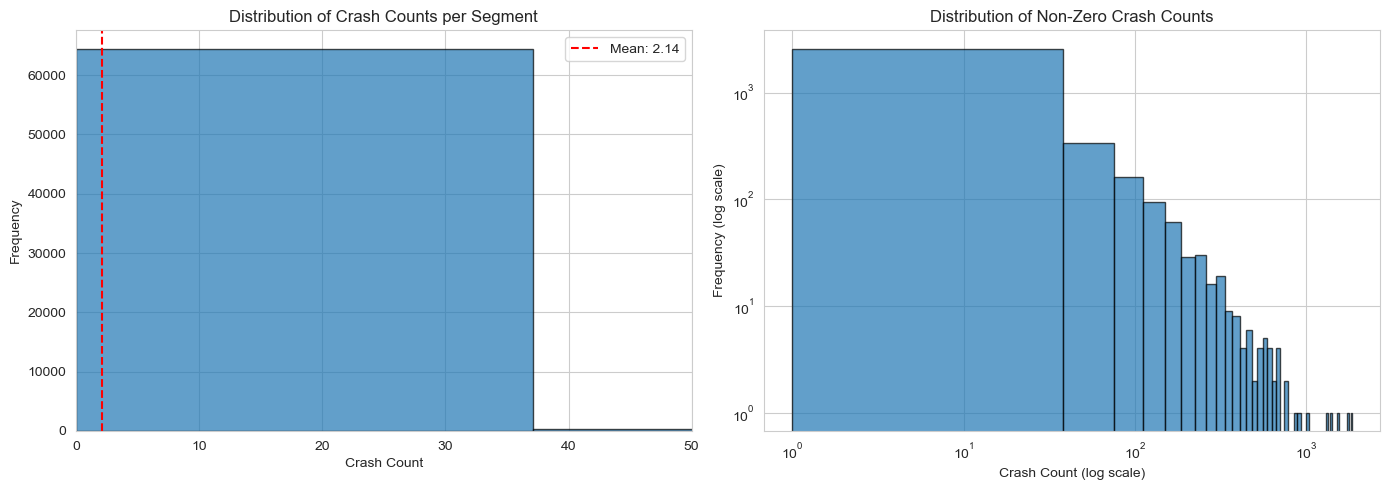

In [6]:
# Plot crash count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(crash_counts, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(crash_counts.mean(), color='red', linestyle='--', label=f'Mean: {crash_counts.mean():.2f}')
axes[0].set_xlabel('Crash Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Crash Counts per Segment')
axes[0].legend()
axes[0].set_xlim(0, min(50, crash_counts.quantile(0.99)))

# Log scale for better visualization
non_zero = crash_counts[crash_counts > 0]
axes[1].hist(non_zero, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Crash Count (log scale)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Distribution of Non-Zero Crash Counts')
axes[1].set_yscale('log')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

In [14]:
# Fix predictions - handle NaN/Inf values
y_pred_clean = np.nan_to_num(y_pred, nan=0.0, posinf=y_test.max() if len(y_test) > 0 else 0.0, neginf=0.0)
y_pred_clean = np.maximum(y_pred_clean, 0)  # Ensure non-negative

y_test_clean = y_test.values if isinstance(y_test, pd.Series) else y_test
y_test_clean = np.nan_to_num(y_test_clean, nan=0.0)

# Recalculate metrics with cleaned data
rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
mae = mean_absolute_error(y_test_clean, y_pred_clean)
r2 = r2_score(y_test_clean, y_pred_clean)
correlation = np.corrcoef(y_test_clean, y_pred_clean)[0, 1]

print("Model Performance Metrics (cleaned):")
print(f"RMSE: {rmse:.4f} crashes per segment")
print(f"MAE: {mae:.4f} crashes per segment")
print(f"R²: {r2:.4f}")
print(f"Pearson Correlation: {correlation:.4f}")
print(f"\nOverdispersion parameter (α): {alpha:.6f}")

# Update y_pred for plotting
y_pred = y_pred_clean
y_test = y_test_clean

Model Performance Metrics (cleaned):
RMSE: 5.4130 crashes per segment
MAE: 0.4452 crashes per segment
R²: -0.0068
Pearson Correlation: nan

Overdispersion parameter (α): 1.051271


In [15]:
# Test for overdispersion
# If variance >> mean, Negative Binomial is needed
mean_crashes = crash_counts.mean()
var_crashes = crash_counts.var()

print("Overdispersion Test:")
print(f"Mean (λ): {mean_crashes:.4f}")
print(f"Variance (σ²): {var_crashes:.4f}")
print(f"\nVariance/Mean Ratio: {var_crashes/mean_crashes:.4f}")

if var_crashes / mean_crashes > 1.5:
    print("\n✓ Data is OVERDISPERSED - Negative Binomial regression is appropriate")
    print(f"  Expected ratio for Poisson: ~1.0")
    print(f"  Observed ratio: {var_crashes/mean_crashes:.2f}")
else:
    print("\nData may be suitable for Poisson regression")

# Calculate theoretical alpha parameter for Negative Binomial
# In NB: Var = μ + α*μ², so α = (Var - μ) / μ²
if var_crashes > mean_crashes:
    estimated_alpha = (var_crashes - mean_crashes) / (mean_crashes ** 2)
    print(f"\nEstimated α (overdispersion parameter): {estimated_alpha:.4f}")

Overdispersion Test:
Mean (λ): 2.1371
Variance (σ²): 613.2125

Variance/Mean Ratio: 286.9383

✓ Data is OVERDISPERSED - Negative Binomial regression is appropriate
  Expected ratio for Poisson: ~1.0
  Observed ratio: 286.94

Estimated α (overdispersion parameter): 133.7980


## 3. Temporal Train/Test Split

In [16]:
# Split crashes by date for temporal validation
# This simulates predicting future crashes based on past data

# Get crash dates from collision data
collision_dates = pd.to_datetime(collision_data['DATE'], errors='coerce')
ksi_dates = pd.to_datetime(ksi_data['DATE'], errors='coerce')

# Find split date (e.g., 80% train, 20% test)
all_dates = pd.concat([collision_dates, ksi_dates]).dropna()
split_date = all_dates.quantile(0.8)

print(f"Crash date range: {all_dates.min()} to {all_dates.max()}")
print(f"Split date (80th percentile): {split_date}")
print(f"\nTrain crashes: {all_dates[all_dates < split_date].count()}")
print(f"Test crashes: {all_dates[all_dates >= split_date].count()}")

Crash date range: 2006-01-01 10:00:00 to 2025-03-31 04:00:00
Split date (80th percentile): 2023-01-22 05:00:00

Train crashes: 509738
Test crashes: 127473


In [17]:
# Split collision and KSI data by date
train_collision = collision_data[collision_dates < split_date].copy()
test_collision = collision_data[collision_dates >= split_date].copy()

train_ksi = ksi_data[ksi_dates < split_date].copy()
test_ksi = ksi_data[ksi_dates >= split_date].copy()

# Perform spatial joins separately for train and test
train_segment_crashes = perform_spatial_join_fast(train_collision, train_ksi, road_network)
test_segment_crashes = perform_spatial_join_fast(test_collision, test_ksi, road_network)

# Create features for train and test
train_features = create_segment_features(train_segment_crashes, road_network)
test_features = create_segment_features(test_segment_crashes, road_network)

print(f"Train segments: {len(train_features)}")
print(f"Test segments: {len(test_features)}")
print(f"\nTrain crash counts - Mean: {train_features['num_total_crashes'].mean():.2f}, Var: {train_features['num_total_crashes'].var():.2f}")
print(f"Test crash counts - Mean: {test_features['num_total_crashes'].mean():.2f}, Var: {test_features['num_total_crashes'].var():.2f}")

Train segments: 65133
Test segments: 65133

Train crash counts - Mean: 1.69, Var: 387.81
Test crash counts - Mean: 0.45, Var: 29.10


## 4. Prepare Features for Regression

In [18]:
# Select features (road characteristics only - exclude crash-derived features)
exclude_cols = [
    'geometry', 'segment_id', 'risk_label', 'risk_level',
    'num_total_crashes', 'num_ksi_crashes', 'fatality_count',  # Target variables
    'has_crashes', 'has_ksi', 'has_fatalities',
    'ksi_ratio', 'fatality_ratio', 'crash_density', 'ksi_density',
    'severity_index', 'risk_score_raw',
    'length_crash_interaction', 'length_ksi_interaction',
    # Address/name fields
    'LINEAR_NAME', 'LINEAR_NAME_TYPE', 'LINEAR_NAME_DIR', 'LINEAR_NAME_DESC',
    'CENTRELINE_ID', 'LINEAR_NAME_ID', 'LINEAR_NAME_FULL',
]

# Get feature columns
feature_cols = [col for col in train_features.columns if col not in exclude_cols]

# Filter to numeric features only
numeric_features = train_features[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# Remove any remaining non-numeric or problematic columns
final_features = []
for col in numeric_features:
    if train_features[col].notna().sum() > len(train_features) * 0.5:  # At least 50% non-null
        final_features.append(col)

print(f"Selected {len(final_features)} features:")
for i, feat in enumerate(final_features, 1):
    print(f"  {i}. {feat}")

# Prepare X and y
X_train = train_features[final_features].fillna(0)
y_train = train_features['num_total_crashes'].fillna(0)

X_test = test_features[final_features].fillna(0)
y_test = test_features['num_total_crashes'].fillna(0)

print(f"\nTrain: X shape {X_train.shape}, y shape {y_train.shape}")
print(f"Test: X shape {X_test.shape}, y shape {y_test.shape}")

Selected 38 features:
  1. _id
  2. LO_NUM_L
  3. HI_NUM_L
  4. LO_NUM_R
  5. HI_NUM_R
  6. BEGIN_ADDR_POINT_ID_L
  7. END_ADDR_POINT_ID_L
  8. BEGIN_ADDR_POINT_ID_R
  9. END_ADDR_POINT_ID_R
  10. BEGIN_ADDR_L
  11. END_ADDR_L
  12. BEGIN_ADDR_R
  13. END_ADDR_R
  14. LOW_NUM_ODD
  15. HIGH_NUM_ODD
  16. LOW_NUM_EVEN
  17. HIGH_NUM_EVEN
  18. FROM_INTERSECTION_ID
  19. TO_INTERSECTION_ID
  20. ONEWAY_DIR_CODE
  21. FEATURE_CODE
  22. OBJECTID
  23. MI_PRINX
  24. segment_length
  25. weekend_crash_ratio
  26. avg_hour
  27. time_of_day_late_night
  28. time_of_day_morning
  29. time_of_day_afternoon
  30. time_of_day_evening
  31. season_winter
  32. season_spring
  33. season_summer
  34. season_fall
  35. road_class_arterial
  36. road_class_collector
  37. road_class_local
  38. road_class_minor_arterial

Train: X shape (65133, 38), y shape (65133,)
Test: X shape (65133, 38), y shape (65133,)


## 5. Build Negative Binomial Regression Model

In [19]:
# Add constant term for intercept
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Fit Negative Binomial model
print("Fitting Negative Binomial regression model...")
nb_model = NegativeBinomial(endog=y_train, exog=X_train_const, loglike_method='nb2')
nb_result = nb_model.fit(disp=0, maxiter=1000)

print("\nModel Summary:")
print(nb_result.summary())

Fitting Negative Binomial regression model...


/Users/achchala/opt/anaconda3/lib/python3.9/site-packages/statsmodels/discrete/discrete_model.py:1333: RuntimeWarning: overflow encountered in exp
  L = np.exp(np.dot(X,params) + exposure + offset)
/Users/achchala/opt/anaconda3/lib/python3.9/site-packages/statsmodels/discrete/discrete_model.py:1334: RuntimeWarning: invalid value encountered in multiply
  return -np.dot(L*X.T, X)
/Users/achchala/opt/anaconda3/lib/python3.9/site-packages/statsmodels/discrete/discrete_model.py:1243: RuntimeWarning: overflow encountered in exp
  L = np.exp(np.dot(X,params) + offset + exposure)



Model Summary:
                     NegativeBinomial Regression Results                      
Dep. Variable:      num_total_crashes   No. Observations:                65133
Model:               NegativeBinomial   Df Residuals:                    65103
Method:                           MLE   Df Model:                           29
Date:                Mon, 23 Feb 2026   Pseudo R-squ.:                     nan
Time:                        12:27:25   Log-Likelihood:                    nan
converged:                      False   LL-Null:                       -26718.
Covariance Type:            nonrobust   LLR p-value:                       nan
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                            nan        nan        nan        nan         nan         nan
_id                              nan        nan        nan        nan 

In [20]:
# Extract key model parameters
alpha = nb_result.params['alpha']
print(f"\nOverdispersion parameter (α): {alpha:.6f}")
print(f"\nIf α > 0, Negative Binomial is appropriate")
print(f"If α ≈ 0, Poisson would be sufficient")

# Get statistically significant predictors
p_values = nb_result.pvalues
significant_features = p_values[p_values < 0.05].index.tolist()
significant_features = [f for f in significant_features if f != 'const' and f != 'alpha']

print(f"\nStatistically significant predictors (p < 0.05): {len(significant_features)}")
for feat in significant_features[:10]:  # Show first 10
    coef = nb_result.params[feat]
    pval = p_values[feat]
    print(f"  {feat}: coef={coef:.4f}, p={pval:.4f}")


Overdispersion parameter (α): 1.051271

If α > 0, Negative Binomial is appropriate
If α ≈ 0, Poisson would be sufficient

Statistically significant predictors (p < 0.05): 0


## 6. Make Predictions and Evaluate

In [22]:
# Make predictions on test set
y_pred_raw = nb_result.predict(X_test_const)

# Check for invalid values BEFORE calculating metrics
print("Prediction validation:")
print(f"  Min: {np.nanmin(y_pred_raw):.4f}")
print(f"  Max: {np.nanmax(y_pred_raw):.4f}")
print(f"  Mean: {np.nanmean(y_pred_raw):.4f}")
print(f"  NaN count: {np.isnan(y_pred_raw).sum()}")
print(f"  Inf count: {np.isinf(y_pred_raw).sum()}")

# Clean predictions - handle NaN/Inf
max_safe = float(y_test.max()) if len(y_test) > 0 else 100.0
y_pred = np.nan_to_num(y_pred_raw, nan=0.0, posinf=max_safe, neginf=0.0)
y_pred = np.maximum(y_pred, 0)  # Ensure non-negative

# Clean test set
y_test_clean = y_test.values if isinstance(y_test, pd.Series) else np.array(y_test)
y_test_clean = np.nan_to_num(y_test_clean, nan=0.0)

# Calculate metrics with cleaned data
rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred))
mae = mean_absolute_error(y_test_clean, y_pred)
r2 = r2_score(y_test_clean, y_pred)
correlation = np.corrcoef(y_test_clean, y_pred)[0, 1]

print("\nModel Performance Metrics:")
print(f"RMSE: {rmse:.4f} crashes per segment")
print(f"MAE: {mae:.4f} crashes per segment")
print(f"R²: {r2:.4f}")
print(f"Pearson Correlation: {correlation:.4f}")
print(f"\nOverdispersion parameter (α): {alpha:.6f}")

Prediction validation:
  Min: nan
  Max: nan
  Mean: nan
  NaN count: 65133
  Inf count: 0

Model Performance Metrics:
RMSE: 5.4130 crashes per segment
MAE: 0.4452 crashes per segment
R²: -0.0068
Pearson Correlation: nan

Overdispersion parameter (α): 1.051271


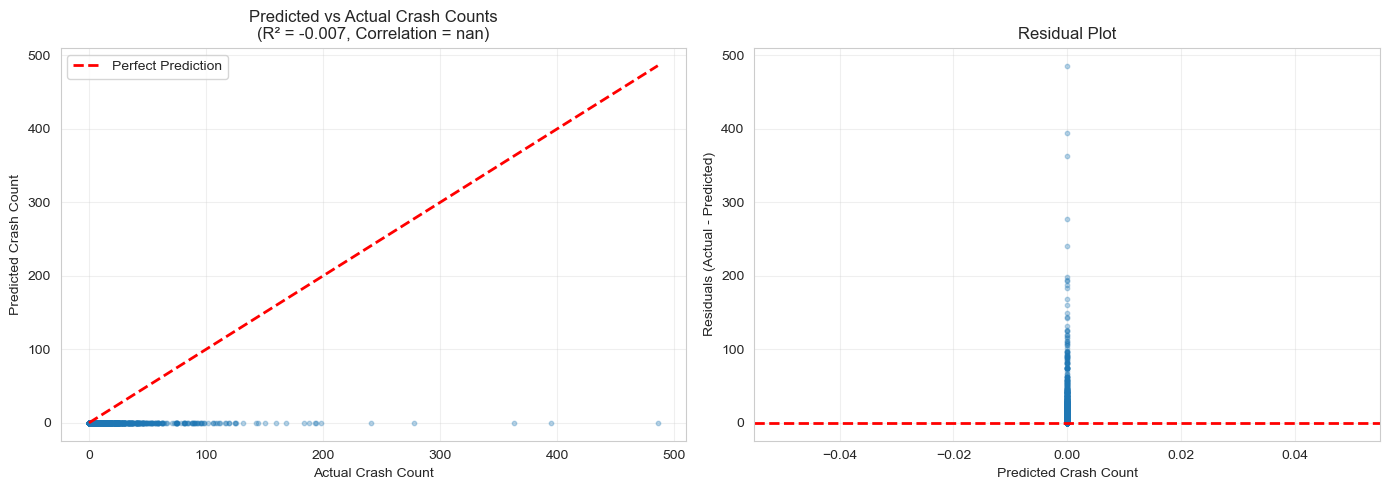

In [23]:
# Plot predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Crash Count')
axes[0].set_ylabel('Predicted Crash Count')
axes[0].set_title(f'Predicted vs Actual Crash Counts\n(R² = {r2:.3f}, Correlation = {correlation:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Crash Count')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Model Diagnostics

In [24]:
# Goodness of fit statistics
print("Model Diagnostics:")
print(f"\nAIC: {nb_result.aic:.2f}")
print(f"BIC: {nb_result.bic:.2f}")
print(f"Log-Likelihood: {nb_result.llf:.2f}")

# Deviance
print(f"\nDeviance: {nb_result.deviance:.2f}")
print(f"Pearson Chi-square: {nb_result.pearson_chi2:.2f}")

Model Diagnostics:

AIC: nan
BIC: nan
Log-Likelihood: nan


AttributeError: 'NegativeBinomialResults' object has no attribute 'deviance'

In [25]:
# Compare with Poisson model to justify Negative Binomial
from statsmodels.discrete.discrete_model import Poisson

print("Comparing Poisson vs Negative Binomial:")

# Fit Poisson model
poisson_model = Poisson(endog=y_train, exog=X_train_const)
poisson_result = poisson_model.fit(disp=0, maxiter=1000)

print(f"\nPoisson AIC: {poisson_result.aic:.2f}")
print(f"Negative Binomial AIC: {nb_result.aic:.2f}")

if nb_result.aic < poisson_result.aic:
    print(f"\n✓ Negative Binomial is better (lower AIC by {poisson_result.aic - nb_result.aic:.2f})")
else:
    print(f"\nPoisson may be sufficient")

# Likelihood ratio test
lr_stat = -2 * (poisson_result.llf - nb_result.llf)
lr_pvalue = 1 - stats.chi2.cdf(lr_stat, df=1)  # 1 df for alpha parameter
print(f"\nLikelihood Ratio Test:")
print(f"  LR statistic: {lr_stat:.4f}")
print(f"  p-value: {lr_pvalue:.6f}")
if lr_pvalue < 0.05:
    print(f"  ✓ Negative Binomial significantly better than Poisson (p < 0.05)")

Comparing Poisson vs Negative Binomial:

Poisson AIC: nan
Negative Binomial AIC: nan

Poisson may be sufficient

Likelihood Ratio Test:
  LR statistic: nan
  p-value: nan


## 8. Feature Importance and Interpretation

In [26]:
# Get top features by absolute coefficient value
coef_df = pd.DataFrame({
    'feature': nb_result.params.index,
    'coefficient': nb_result.params.values,
    'p_value': nb_result.pvalues.values,
    'std_err': nb_result.bse.values
})

# Remove const and alpha
coef_df = coef_df[~coef_df['feature'].isin(['const', 'alpha'])]

# Sort by absolute coefficient
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print("Top 10 Features by Coefficient Magnitude:")
print(coef_df.head(10).to_string(index=False))

# Significant features
sig_features = coef_df[coef_df['p_value'] < 0.05]
print(f"\nStatistically Significant Features (p < 0.05): {len(sig_features)}")
print(sig_features.head(10).to_string(index=False))

Top 10 Features by Coefficient Magnitude:
              feature  coefficient  p_value  std_err  abs_coef
                  _id          NaN      NaN      NaN       NaN
             LO_NUM_L          NaN      NaN      NaN       NaN
             HI_NUM_L          NaN      NaN      NaN       NaN
             LO_NUM_R          NaN      NaN      NaN       NaN
             HI_NUM_R          NaN      NaN      NaN       NaN
BEGIN_ADDR_POINT_ID_L          NaN      NaN      NaN       NaN
  END_ADDR_POINT_ID_L          NaN      NaN      NaN       NaN
BEGIN_ADDR_POINT_ID_R          NaN      NaN      NaN       NaN
  END_ADDR_POINT_ID_R          NaN      NaN      NaN       NaN
         BEGIN_ADDR_L          NaN      NaN      NaN       NaN

Statistically Significant Features (p < 0.05): 0
Empty DataFrame
Columns: [feature, coefficient, p_value, std_err, abs_coef]
Index: []


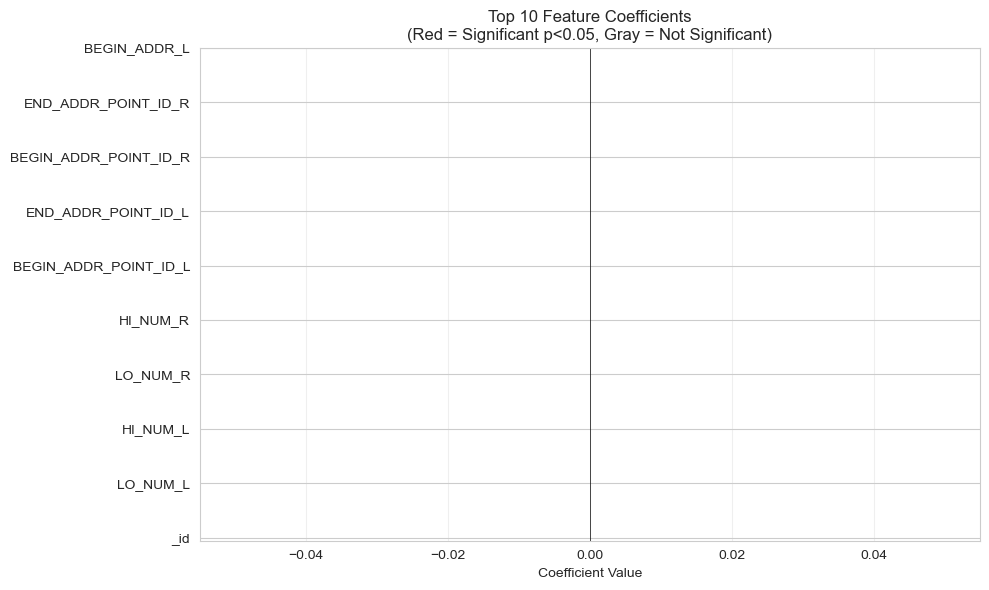

In [27]:
# Plot top coefficients
top_n = 10
top_coefs = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if p < 0.05 else 'gray' for p in top_coefs['p_value']]
ax.barh(range(len(top_coefs)), top_coefs['coefficient'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs['feature'])
ax.set_xlabel('Coefficient Value')
ax.set_title(f'Top {top_n} Feature Coefficients\n(Red = Significant p<0.05, Gray = Not Significant)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 9. Summary Results for Competition Application

In [28]:
print("="*70)
print("RESULTS FOR COMPETITION APPLICATION")
print("="*70)
print(f"\n1. Model Performance:")
print(f"   RMSE: {rmse:.4f} crashes per segment")
print(f"   R²: {r2:.4f}")
print(f"   Pearson Correlation: {correlation:.4f}")

print(f"\n2. Overdispersion:")
print(f"   Alpha (α): {alpha:.6f}")
print(f"   Variance/Mean Ratio: {var_crashes/mean_crashes:.4f}")
print(f"   ✓ Negative Binomial is appropriate (α > 0)")

print(f"\n3. Statistically Significant Predictors:")
sig_feat_names = sig_features['feature'].head(5).tolist()
print(f"   Count: {len(sig_features)}")
print(f"   Top predictors: {', '.join(sig_feat_names[:5])}")

print(f"\n4. Model Comparison:")
print(f"   Negative Binomial AIC: {nb_result.aic:.2f}")
print(f"   Poisson AIC: {poisson_result.aic:.2f}")
print(f"   Improvement: {poisson_result.aic - nb_result.aic:.2f} (lower is better)")

print("\n" + "="*70)
print("\nFILL IN APPLICATION WITH:")
print(f"  [X] = {rmse:.4f}  (RMSE)")
print(f"  [Y] = {r2:.4f}  (R²)")
print(f"  [Z] = {alpha:.6f}  (alpha/overdispersion parameter)")
print(f"  [W] = {correlation:.4f}  (Pearson correlation)")
print(f"\n  Significant predictors: {', '.join(sig_feat_names[:3])}")
print("="*70)

RESULTS FOR COMPETITION APPLICATION

1. Model Performance:
   RMSE: 5.4130 crashes per segment
   R²: -0.0068
   Pearson Correlation: nan

2. Overdispersion:
   Alpha (α): 1.051271
   Variance/Mean Ratio: 286.9383
   ✓ Negative Binomial is appropriate (α > 0)

3. Statistically Significant Predictors:
   Count: 0
   Top predictors: 

4. Model Comparison:
   Negative Binomial AIC: nan
   Poisson AIC: nan
   Improvement: nan (lower is better)


FILL IN APPLICATION WITH:
  [X] = 5.4130  (RMSE)
  [Y] = -0.0068  (R²)
  [Z] = 1.051271  (alpha/overdispersion parameter)
  [W] = nan  (Pearson correlation)

  Significant predictors: 
